# Freight Rate Analysis Dashboard

This notebook analyzes freight rate data from the MPACT API, providing insights into lane rates, trailer type pricing, and predictive modeling.

## 1. Import Libraries
Essential data analysis, visualization, and machine learning libraries are imported.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid")

## 2. Load Data
Load the MPACT rates CSV file containing freight rate data.

In [13]:
csv_path = Path("../data/mpact_rates.csv")

if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f"Loaded {len(df):,} rows from '{csv_path}'")
    print("\nFirst 5 rows:")
    print(df.head())
    
    print("\nColumn names:")
    print(df.columns.tolist())
    
    if 'include_fuel' in df.columns:
        print(f"\nUnique values in include_fuel column:")
        print(df['include_fuel'].value_counts())
    
    print("\nData types:")
    print(df.dtypes)
else:
    print(f"File not found at '{csv_path}'. Please check the path.")
    df = pd.DataFrame()

Loaded 1,200 rows from '..\data\mpact_rates.csv'

First 5 rows:
                   pulled_at endpoint_type  origin_zip3  destination_zip3  \
0  2026-01-06T16:46:26+00:00           buy          900               606   
1  2026-01-06T16:46:28+00:00           buy          900               606   
2  2026-01-06T16:46:29+00:00          sell          900               606   
3  2026-01-06T16:46:31+00:00          sell          900               606   
4  2026-01-06T16:46:32+00:00           buy          900               606   

  trailer_type carrier_type  include_fuel  include_quartiles  average  \
0          Van       Broker          True               True     2.69   
1          Van       Broker         False               True     2.25   
2          Van        Asset          True               True     2.50   
3          Van        Asset         False               True     2.04   
4      Flatbed       Broker          True               True     1.97   

   minimum  maximum  quartile1  qu

## 3. Data Cleaning and Exploration
Convert data types, check for missing values, and clean the dataset by removing rows with null rates.

In [14]:
if not df.empty:
    if 'pulled_at' in df.columns:
        df['pulled_at'] = pd.to_datetime(df['pulled_at'])
    
    required_cols = ['average', 'minimum', 'maximum']
    if all(col in df.columns for col in required_cols):
        df_clean = df.dropna(subset=required_cols)
        print(f"Rows after cleaning: {len(df_clean):,}")
        
        if 'include_fuel' in df_clean.columns:
            df_clean['fuel_label'] = df_clean['include_fuel'].map({True: 'With Fuel', False: 'Without Fuel'})
            print(f"\nFuel inclusion breakdown:")
            print(df_clean['fuel_label'].value_counts())
    else:
        print(f"Missing required columns. Available: {df.columns.tolist()}")
        df_clean = pd.DataFrame()
else:
    print("No data available for analysis.")
    df_clean = pd.DataFrame()

Rows after cleaning: 1,200

Fuel inclusion breakdown:
fuel_label
With Fuel       600
Without Fuel    600
Name: count, dtype: int64


## 4. Lane Analysis
Identify the most frequently requested freight lanes based on data collection patterns.

In [15]:
if not df_clean.empty and 'origin_zip3' in df_clean.columns and 'destination_zip3' in df_clean.columns:
    
    if 'include_fuel' in df_clean.columns:
        print("=== Lanes WITH Fuel ===")
        lanes_with_fuel = df_clean[df_clean['include_fuel'] == True].copy()  # Use .copy() to avoid SettingWithCopyWarning
        lane_counts_with = lanes_with_fuel.groupby(['origin_zip3', 'destination_zip3']).size().reset_index(name='count')
        top_lanes_with = lane_counts_with.sort_values(by='count', ascending=False).head(10)
        print(top_lanes_with)
        
        print("\n=== Lanes WITHOUT Fuel ===")
        lanes_without_fuel = df_clean[df_clean['include_fuel'] == False].copy() 
        lane_counts_without = lanes_without_fuel.groupby(['origin_zip3', 'destination_zip3']).size().reset_index(name='count')
        top_lanes_without = lane_counts_without.sort_values(by='count', ascending=False).head(10)
        print(top_lanes_without)
        
        print("\n=== Fuel Surcharge Analysis ===")
        lanes_with_fuel['lane_key'] = lanes_with_fuel['origin_zip3'].astype(str) + '_' + lanes_with_fuel['destination_zip3'].astype(str) + '_' + lanes_with_fuel['trailer_type'] + '_' + lanes_with_fuel['carrier_type']
        lanes_without_fuel['lane_key'] = lanes_without_fuel['origin_zip3'].astype(str) + '_' + lanes_without_fuel['destination_zip3'].astype(str) + '_' + lanes_without_fuel['trailer_type'] + '_' + lanes_without_fuel['carrier_type']
        
        merged_lanes = pd.merge(
            lanes_with_fuel[['lane_key', 'average', 'trailer_type', 'carrier_type', 'endpoint_type']],
            lanes_without_fuel[['lane_key', 'average']],
            on='lane_key',
            suffixes=('_with_fuel', '_without_fuel'),
            how='inner'
        )
        
        if not merged_lanes.empty:
            merged_lanes['fuel_surcharge'] = merged_lanes['average_with_fuel'] - merged_lanes['average_without_fuel']
            merged_lanes['fuel_surcharge_pct'] = (merged_lanes['fuel_surcharge'] / merged_lanes['average_without_fuel']) * 100
            
            print(f"Found {len(merged_lanes)} matching lanes with both fuel settings")
            print("\nFuel surcharge statistics:")
            print(f"Average surcharge: ${merged_lanes['fuel_surcharge'].mean():.2f}")
            print(f"Min surcharge: ${merged_lanes['fuel_surcharge'].min():.2f}")
            print(f"Max surcharge: ${merged_lanes['fuel_surcharge'].max():.2f}")
            print(f"Average % surcharge: {merged_lanes['fuel_surcharge_pct'].mean():.1f}%")
            
            print("\nTop 10 lanes with highest fuel surcharge:")
            top_surcharge = merged_lanes.sort_values('fuel_surcharge', ascending=False).head(10)
            for idx, row in top_surcharge.iterrows():
                print(f"{row['trailer_type']} - {row['carrier_type']} - {row['endpoint_type']}: "
                        f"${row['fuel_surcharge']:.2f} ({row['fuel_surcharge_pct']:.1f}%)")
            
            print("\nAverage fuel surcharge by trailer type:")
            trailer_surcharge = merged_lanes.groupby('trailer_type').agg({
                'fuel_surcharge': 'mean',
                'fuel_surcharge_pct': 'mean'
            }).round(2)
            print(trailer_surcharge)
            
            fuel_surcharge_df = merged_lanes.copy()
        else:
            print("No matching lanes found with both fuel settings")
            fuel_surcharge_df = pd.DataFrame()
    
    else:
        print("No fuel inclusion data available for separation.")
else:
    print("Cannot perform lane analysis - required columns missing or no data available.")

=== Lanes WITH Fuel ===
   origin_zip3  destination_zip3  count
0           21               100      6
1          100                21      6
2          100               191      6
3          100               212      6
4          100               303      6
5          100               331      6
6          100               606      6
7          100               750      6
8          100               770      6
9          100               900      6

=== Lanes WITHOUT Fuel ===
   origin_zip3  destination_zip3  count
0           21               100      6
1          100                21      6
2          100               191      6
3          100               212      6
4          100               303      6
5          100               331      6
6          100               606      6
7          100               750      6
8          100               770      6
9          100               900      6

=== Fuel Surcharge Analysis ===
Found 600 matching lanes with both 

## 5. Trailer Type Summary Statistics
Visualize key statistics for each trailer type including average rates, variability, and rate ranges.


With Fuel Statistics:
  trailer_type  Request_Count  Avg_Rate  Min_Rate  Max_Rate  Rate_Std_Dev
0      Flatbed            200   2.57805       0.0      9.39      1.495810
1       Reefer            200   2.58585       0.0      7.81      1.459366
2          Van            200   2.55410       0.0      7.28      1.173320

Without Fuel Statistics:
  trailer_type  Request_Count  Avg_Rate  Min_Rate  Max_Rate  Rate_Std_Dev
0      Flatbed            200    2.1776       0.0      8.24      1.371507
1       Reefer            200    2.1974       0.0      7.37      1.359176
2          Van            200    2.1253       0.0      6.84      1.131867


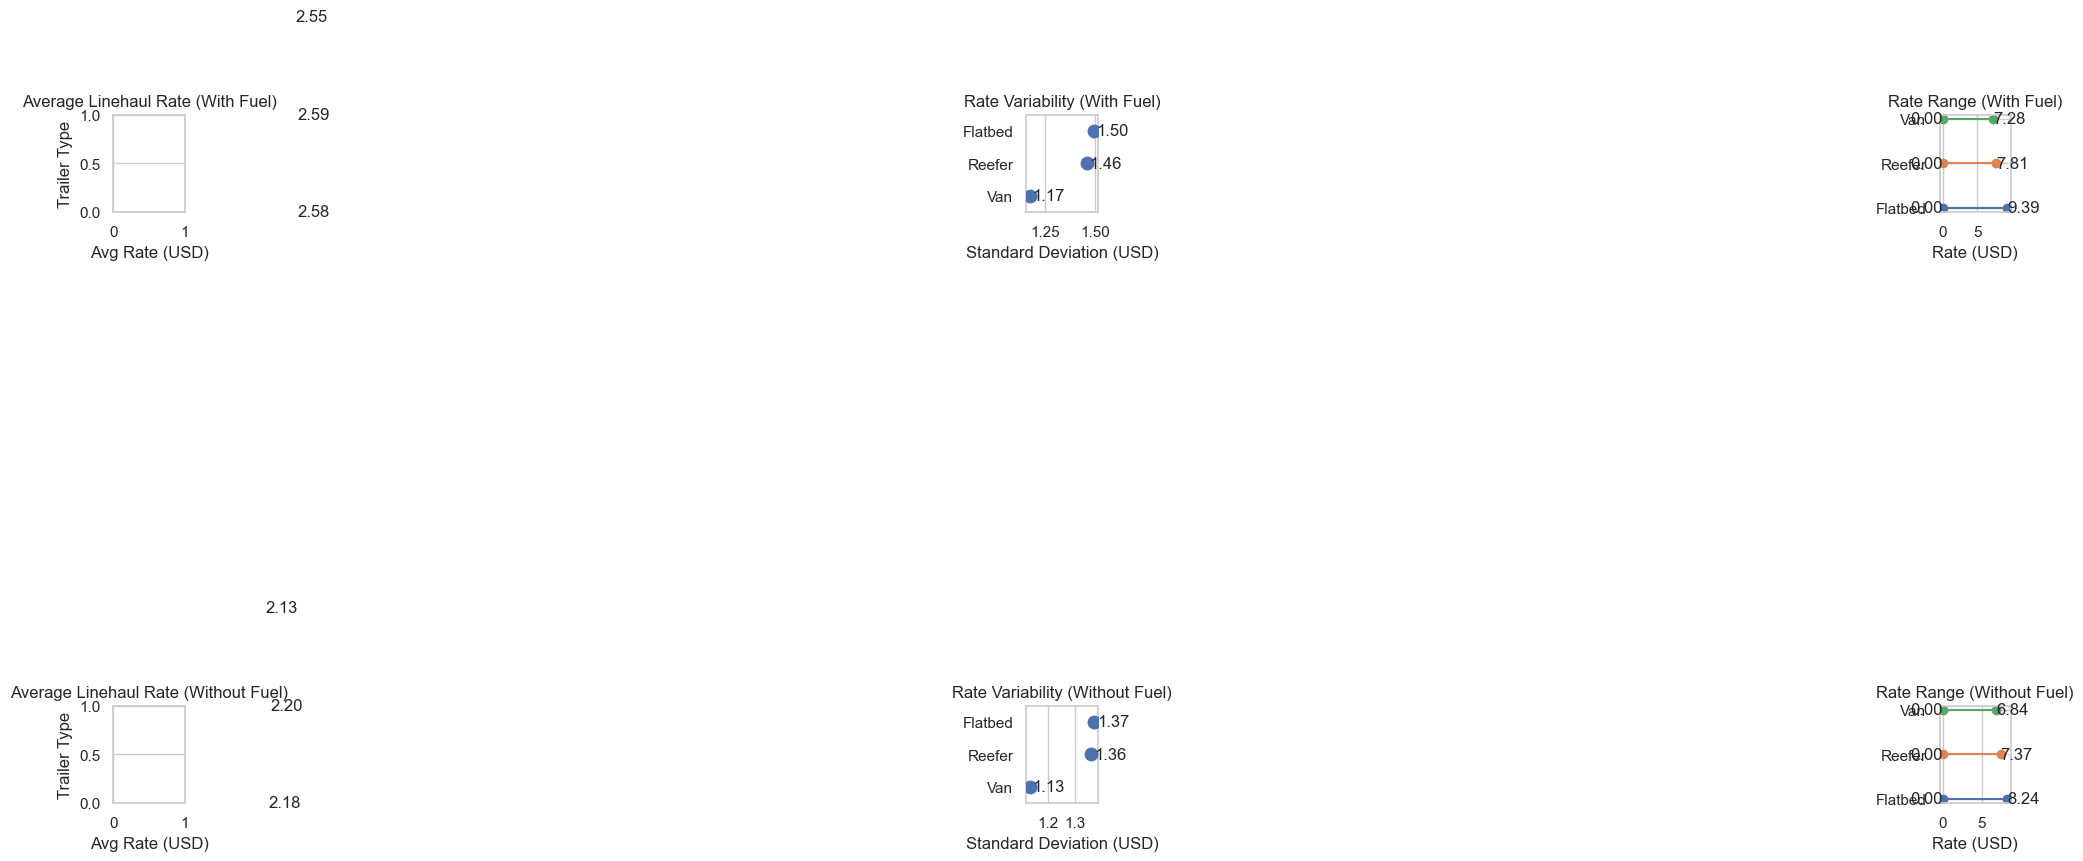

In [16]:
if not df_clean.empty and 'trailer_type' in df_clean.columns and 'average' in df_clean.columns:
    
    if 'include_fuel' in df_clean.columns:
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        
        for idx, fuel_status in enumerate([True, False]):
            fuel_label = 'With Fuel' if fuel_status else 'Without Fuel'
            df_subset = df_clean[df_clean['include_fuel'] == fuel_status]
            
            if not df_subset.empty:
                summary_stats = (
                    df_subset.groupby('trailer_type')['average']
                    .agg(['count', 'mean', 'min', 'max', 'std'])
                    .reset_index()
                    .rename(columns={
                        'count': 'Request_Count',
                        'mean': 'Avg_Rate',
                        'min': 'Min_Rate',
                        'max': 'Max_Rate',
                        'std': 'Rate_Std_Dev'
                    })
                )
                
                # Plot 1: Average Rate
                for i, row in summary_stats.iterrows():
                    axes[idx, 0].text(row['Avg_Rate'] + 0.01, i, f"{row['Avg_Rate']:.2f}", va='center')
                axes[idx, 0].set_title(f'Average Linehaul Rate ({fuel_label})')
                axes[idx, 0].set_xlabel('Avg Rate (USD)')
                axes[idx, 0].set_ylabel('Trailer Type')
                
                # Plot 2: Rate Variability
                sns.stripplot(data=summary_stats, x='Rate_Std_Dev', y='trailer_type', size=10, ax=axes[idx, 1])
                for i, row in summary_stats.iterrows():
                    axes[idx, 1].text(row['Rate_Std_Dev'] + 0.01, i, f"{row['Rate_Std_Dev']:.2f}", va='center')
                axes[idx, 1].set_title(f'Rate Variability ({fuel_label})')
                axes[idx, 1].set_xlabel('Standard Deviation (USD)')
                axes[idx, 1].set_ylabel('')
                
                # Plot 3: Rate Range
                for i, row in summary_stats.iterrows():
                    axes[idx, 2].plot([row['Min_Rate'], row['Max_Rate']], [row['trailer_type']] * 2, marker='o')
                    axes[idx, 2].text(row['Min_Rate'], i, f"{row['Min_Rate']:.2f}", va='center', ha='right')
                    axes[idx, 2].text(row['Max_Rate'], i, f"{row['Max_Rate']:.2f}", va='center', ha='left')
                axes[idx, 2].set_title(f'Rate Range ({fuel_label})')
                axes[idx, 2].set_xlabel('Rate (USD)')
                axes[idx, 2].set_ylabel('')
                
                print(f"\n{fuel_label} Statistics:")
                print(summary_stats)
            else:
                axes[idx, 0].text(0.5, 0.5, f'No data for {fuel_label}', 
                                    ha='center', va='center', transform=axes[idx, 0].transAxes)
        
        plt.tight_layout()
        plt.show()
        
    else:
        summary_stats = (
            df_clean.groupby('trailer_type')['average']
            .agg(['count', 'mean', 'min', 'max', 'std'])
            .reset_index()
            .rename(columns={
                'count': 'Request_Count',
                'mean': 'Avg_Rate',
                'min': 'Min_Rate',
                'max': 'Max_Rate',
                'std': 'Rate_Std_Dev'
            })
        )
        
        print("Trailer Type Statistics (All Data Combined):")
        print(summary_stats)
        
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        
        for i, row in summary_stats.iterrows():
            axes[0].text(row['Avg_Rate'] + 0.01, i, f"{row['Avg_Rate']:.2f}", va='center')
        axes[0].set_title('Average Linehaul Rate by Trailer Type')
        axes[0].set_xlabel('Avg Rate (USD)')
        axes[0].set_ylabel('Trailer Type')
        
        sns.stripplot(data=summary_stats, x='Rate_Std_Dev', y='trailer_type', size=10, ax=axes[1])
        for i, row in summary_stats.iterrows():
            axes[1].text(row['Rate_Std_Dev'] + 0.01, i, f"{row['Rate_Std_Dev']:.2f}", va='center')
        axes[1].set_title('Rate Variability by Trailer Type')
        axes[1].set_xlabel('Standard Deviation (USD)')
        axes[1].set_ylabel('')
        
        for i, row in summary_stats.iterrows():
            axes[2].plot([row['Min_Rate'], row['Max_Rate']], [row['trailer_type']] * 2, marker='o')
            axes[2].text(row['Min_Rate'], i, f"{row['Min_Rate']:.2f}", va='center', ha='right')
            axes[2].text(row['Max_Rate'], i, f"{row['Max_Rate']:.2f}", va='center', ha='left')
        axes[2].set_title('Rate Range by Trailer Type')
        axes[2].set_xlabel('Rate (USD)')
        axes[2].set_ylabel('')
        
        plt.tight_layout()
        plt.show()
else:
    print("Cannot create trailer type statistics - required columns missing.")

## 6. Top Lanes Rate Visualization
Display average freight rates for the top 20 most frequently requested lanes in descending order.

=== Detailed Fuel Surcharge Analysis ===
Total comparable combinations: 6

Overall Statistics:
Average base rate (without fuel): $2.17
Average rate with fuel: $2.57
Average fuel surcharge: $0.41
Average % surcharge: 18.8%

=== By Trailer Type ===

Van:
  Avg surcharge: $0.43
  Avg % surcharge: 20.2%
  Range: $0.42 to $0.44

Flatbed:
  Avg surcharge: $0.40
  Avg % surcharge: 18.4%
  Range: $0.38 to $0.42

Reefer:
  Avg surcharge: $0.39
  Avg % surcharge: 17.8%
  Range: $0.35 to $0.43

=== By Carrier Type ===

Broker:
  Avg surcharge: $0.43
  Avg % surcharge: 19.0%

Asset:
  Avg surcharge: $0.38
  Avg % surcharge: 18.6%

Detailed fuel surcharge data saved to 'fuel_surcharge_detailed.csv'


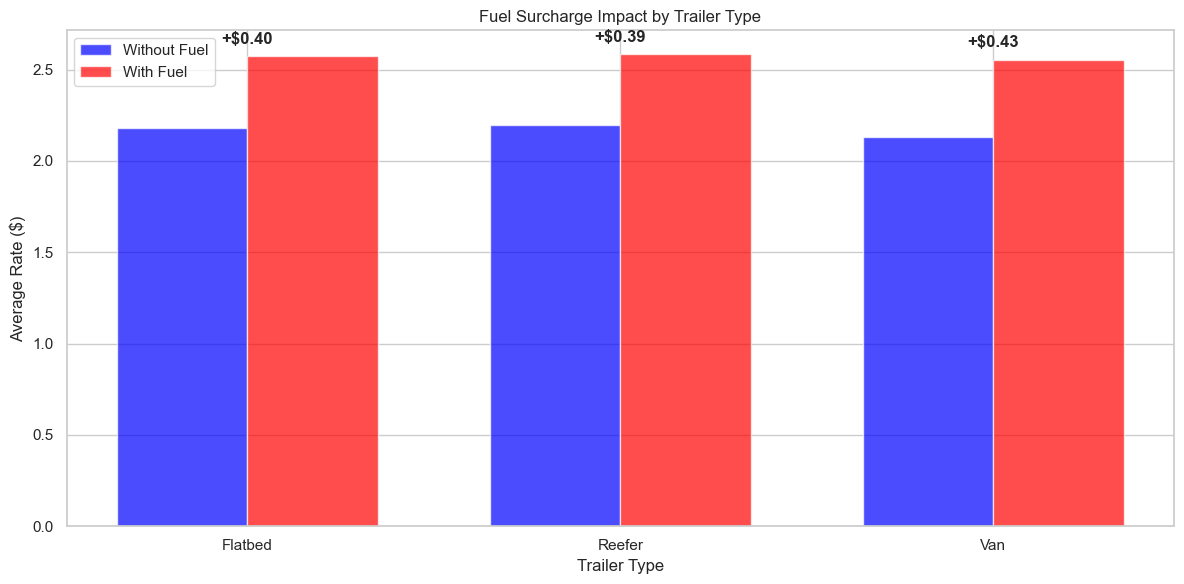

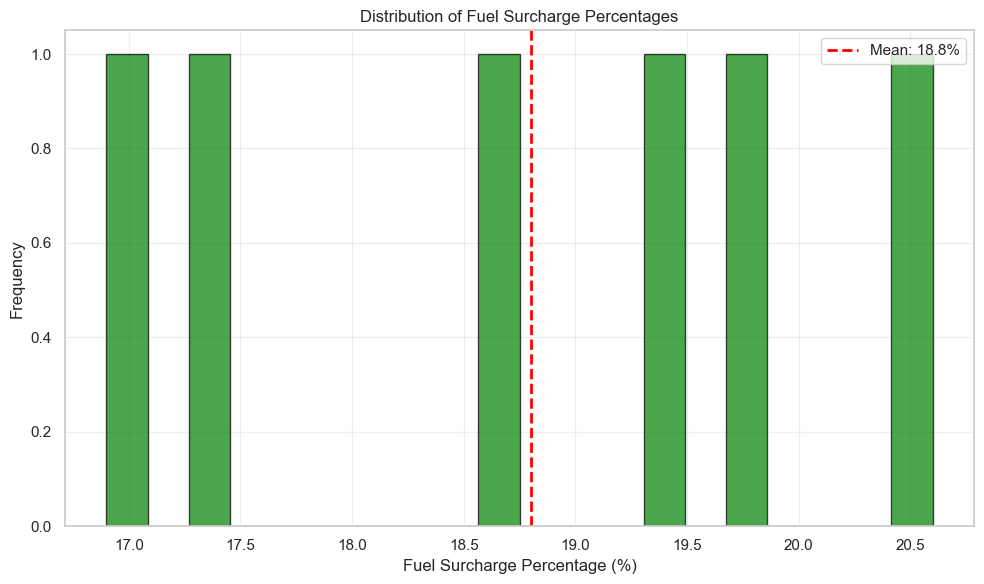

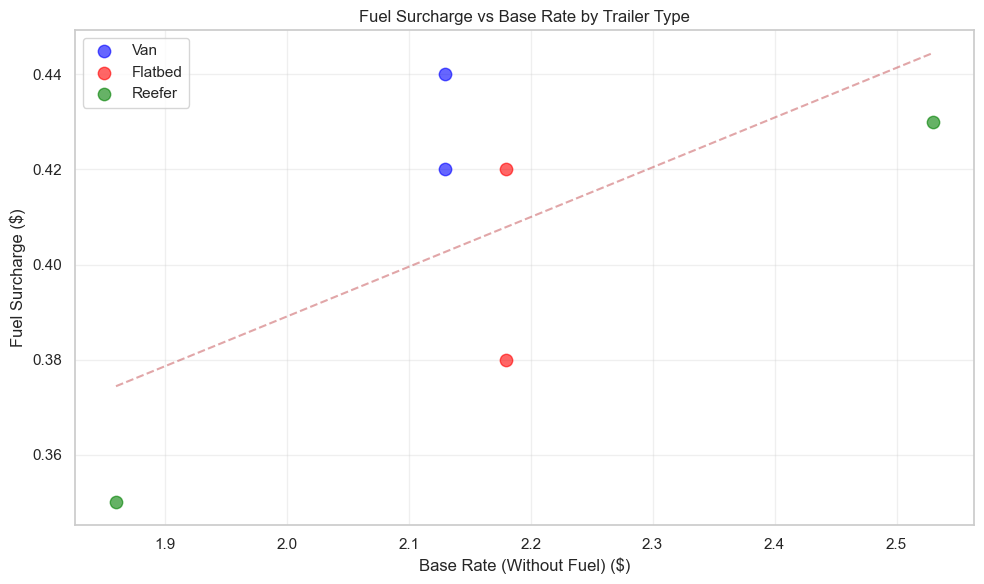

In [17]:
if not df_clean.empty and 'include_fuel' in df_clean.columns:
    
    comparison_data = []
    
    for trailer in df_clean['trailer_type'].unique():
        for carrier in df_clean['carrier_type'].unique():
            for endpoint in df_clean['endpoint_type'].unique():
                # With fuel rates
                with_fuel = df_clean[(df_clean['trailer_type'] == trailer) & 
                                    (df_clean['carrier_type'] == carrier) & 
                                    (df_clean['endpoint_type'] == endpoint) & 
                                    (df_clean['include_fuel'] == True)].copy()
                
                # Without fuel rates
                without_fuel = df_clean[(df_clean['trailer_type'] == trailer) & 
                                        (df_clean['carrier_type'] == carrier) & 
                                        (df_clean['endpoint_type'] == endpoint) & 
                                        (df_clean['include_fuel'] == False)].copy()
                
                if not with_fuel.empty and not without_fuel.empty:
                    avg_with = with_fuel['average'].mean()
                    avg_without = without_fuel['average'].mean()
                    fuel_diff = avg_with - avg_without
                    fuel_pct = (fuel_diff / avg_without) * 100 if avg_without > 0 else 0
                    
                    comparison_data.append({
                        'trailer_type': trailer,
                        'carrier_type': carrier,
                        'endpoint_type': endpoint,
                        'avg_without_fuel': round(avg_without, 2),
                        'avg_with_fuel': round(avg_with, 2),
                        'fuel_surcharge': round(fuel_diff, 2),
                        'fuel_surcharge_pct': round(fuel_pct, 1),
                        'count_with_fuel': len(with_fuel),
                        'count_without_fuel': len(without_fuel),
                        'sample_size': min(len(with_fuel), len(without_fuel))
                    })
    
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        
        print("=== Detailed Fuel Surcharge Analysis ===")
        print(f"Total comparable combinations: {len(comparison_df)}")
        
        print("\nOverall Statistics:")
        print(f"Average base rate (without fuel): ${comparison_df['avg_without_fuel'].mean():.2f}")
        print(f"Average rate with fuel: ${comparison_df['avg_with_fuel'].mean():.2f}")
        print(f"Average fuel surcharge: ${comparison_df['fuel_surcharge'].mean():.2f}")
        print(f"Average % surcharge: {comparison_df['fuel_surcharge_pct'].mean():.1f}%")
        
        # Breakdown by trailer type
        print("\n=== By Trailer Type ===")
        for trailer in comparison_df['trailer_type'].unique():
            trailer_data = comparison_df[comparison_df['trailer_type'] == trailer]
            print(f"\n{trailer}:")
            print(f"  Avg surcharge: ${trailer_data['fuel_surcharge'].mean():.2f}")
            print(f"  Avg % surcharge: {trailer_data['fuel_surcharge_pct'].mean():.1f}%")
            print(f"  Range: ${trailer_data['fuel_surcharge'].min():.2f} to ${trailer_data['fuel_surcharge'].max():.2f}")
        
        # Breakdown by carrier type
        print("\n=== By Carrier Type ===")
        for carrier in comparison_df['carrier_type'].unique():
            carrier_data = comparison_df[comparison_df['carrier_type'] == carrier]
            print(f"\n{carrier}:")
            print(f"  Avg surcharge: ${carrier_data['fuel_surcharge'].mean():.2f}")
            print(f"  Avg % surcharge: {carrier_data['fuel_surcharge_pct'].mean():.1f}%")
        
        comparison_df.to_csv("fuel_surcharge_detailed.csv", index=False)
        print("\nDetailed fuel surcharge data saved to 'fuel_surcharge_detailed.csv'")
        
        # Fuel surcharge by trailer
        plt.figure(figsize=(12, 6))
        
        trailer_avg = comparison_df.groupby('trailer_type').agg({
            'avg_without_fuel': 'mean',
            'avg_with_fuel': 'mean',
            'fuel_surcharge': 'mean'
        }).reset_index()
        
        x = np.arange(len(trailer_avg))
        width = 0.35
        
        plt.bar(x - width/2, trailer_avg['avg_without_fuel'], width, 
                label='Without Fuel', color='blue', alpha=0.7)
        plt.bar(x + width/2, trailer_avg['avg_with_fuel'], width, 
                label='With Fuel', color='red', alpha=0.7)
        
        for i, row in trailer_avg.iterrows():
            plt.text(x[i], row['avg_with_fuel'] + 0.05, f"+${row['fuel_surcharge']:.2f}", 
                    ha='center', va='bottom', fontweight='bold')
        
        plt.xlabel('Trailer Type')
        plt.ylabel('Average Rate ($)')
        plt.title('Fuel Surcharge Impact by Trailer Type')
        plt.xticks(x, trailer_avg['trailer_type'])
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        # Fuel surcharge percentage distribution
        plt.figure(figsize=(10, 6))
        
        # Histogram
        plt.hist(comparison_df['fuel_surcharge_pct'], bins=20, alpha=0.7, color='green', edgecolor='black')
        plt.axvline(comparison_df['fuel_surcharge_pct'].mean(), color='red', linestyle='--', 
                    linewidth=2, label=f"Mean: {comparison_df['fuel_surcharge_pct'].mean():.1f}%")
        
        plt.xlabel('Fuel Surcharge Percentage (%)')
        plt.ylabel('Frequency')
        plt.title('Distribution of Fuel Surcharge Percentages')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Scatter plot of base rate vs fuel surcharge
        plt.figure(figsize=(10, 6))
        
        colors = {'Van': 'blue', 'Flatbed': 'red', 'Reefer': 'green'}
        
        for trailer in comparison_df['trailer_type'].unique():
            subset = comparison_df[comparison_df['trailer_type'] == trailer]
            plt.scatter(subset['avg_without_fuel'], subset['fuel_surcharge'], 
                        c=colors[trailer], label=trailer, alpha=0.6, s=80)
        
        plt.xlabel('Base Rate (Without Fuel) ($)')
        plt.ylabel('Fuel Surcharge ($)')
        plt.title('Fuel Surcharge vs Base Rate by Trailer Type')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        z = np.polyfit(comparison_df['avg_without_fuel'], comparison_df['fuel_surcharge'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(comparison_df['avg_without_fuel'].min(), comparison_df['avg_without_fuel'].max(), 100)
        plt.plot(x_range, p(x_range), "r--", alpha=0.5, label='Trend line')
        
        plt.tight_layout()
        plt.show()
        
    else:
        print("No comparable data found for fuel surcharge analysis.")
else:
    print("Cannot perform fuel surcharge analysis - fuel inclusion data missing.")

## 7. Distribution Analysis by Trailer and Carrier Type
Compare rate distributions across different trailer types and carrier types using box plots.

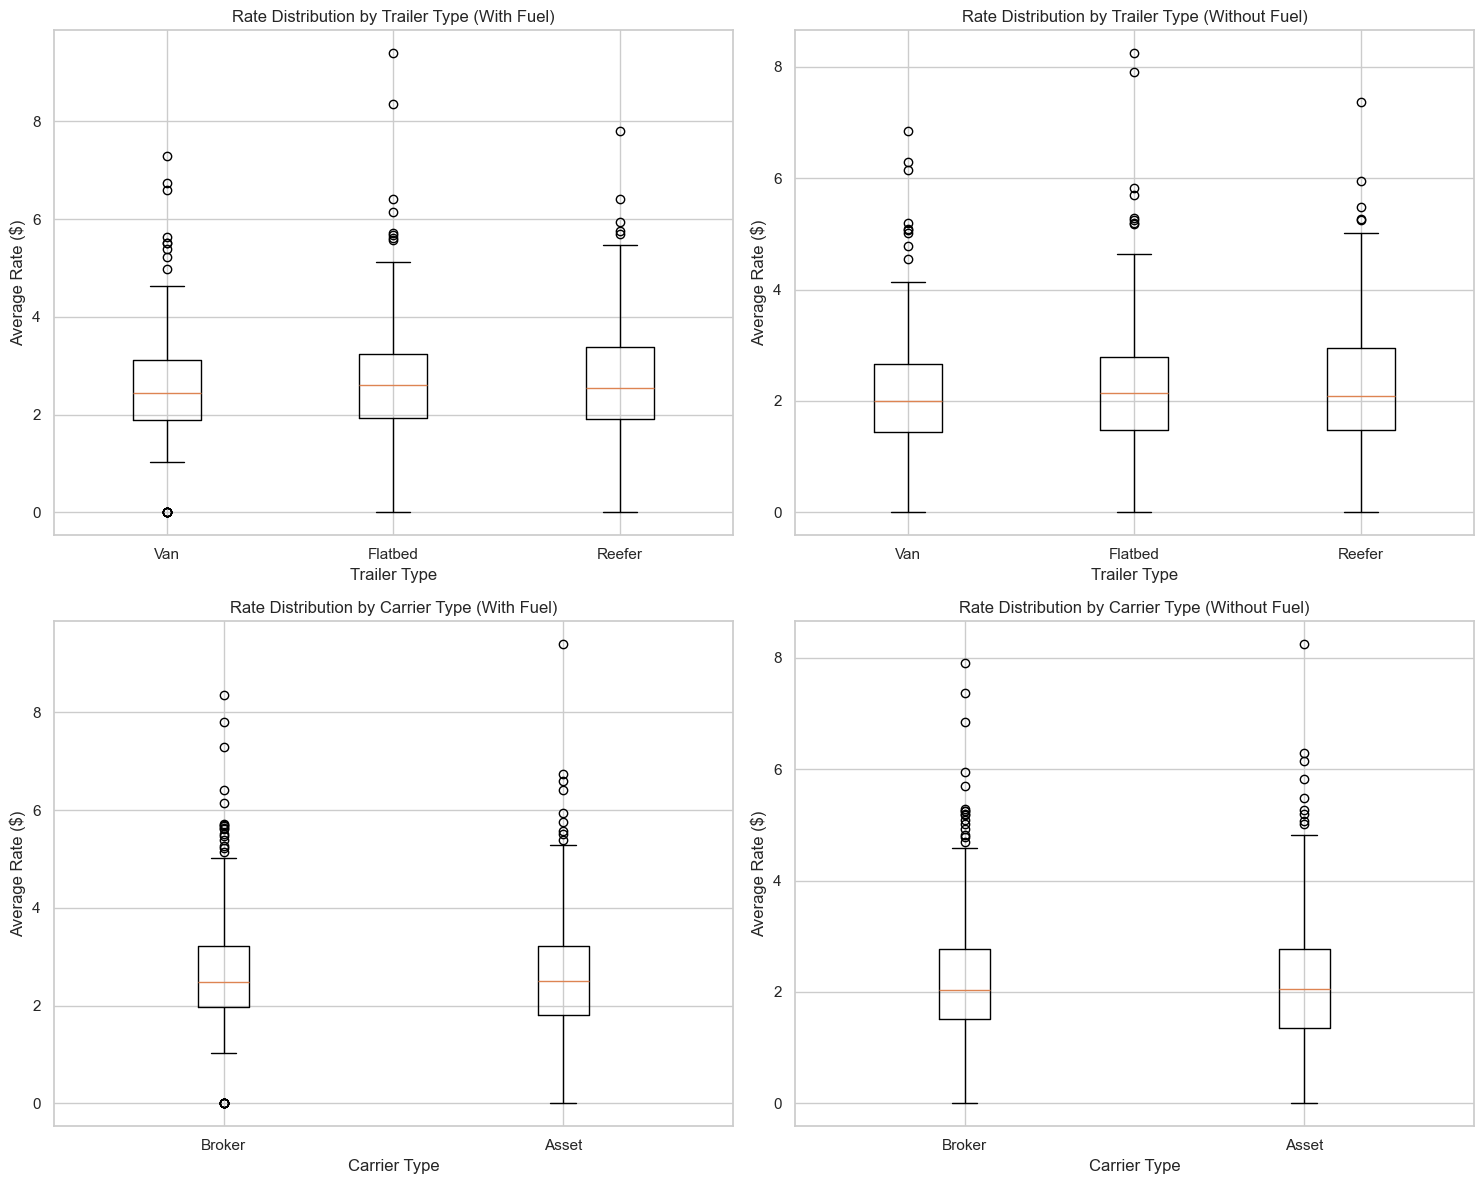

In [18]:
if not df_clean.empty:
    
    if 'include_fuel' in df_clean.columns:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Trailer - With Fuel
        axes[0, 0].boxplot([df_clean[(df_clean['trailer_type'] == trailer) & 
                                    (df_clean['include_fuel'] == True)]['average'].values 
                            for trailer in df_clean['trailer_type'].unique() 
                            if not df_clean[(df_clean['trailer_type'] == trailer) & 
                                            (df_clean['include_fuel'] == True)].empty])
        axes[0, 0].set_xticklabels(df_clean['trailer_type'].unique())
        axes[0, 0].set_title('Rate Distribution by Trailer Type (With Fuel)')
        axes[0, 0].set_xlabel('Trailer Type')
        axes[0, 0].set_ylabel('Average Rate ($)')
        
        # Trailer - Without Fuel
        axes[0, 1].boxplot([df_clean[(df_clean['trailer_type'] == trailer) & 
                                    (df_clean['include_fuel'] == False)]['average'].values 
                            for trailer in df_clean['trailer_type'].unique() 
                            if not df_clean[(df_clean['trailer_type'] == trailer) & 
                                            (df_clean['include_fuel'] == False)].empty])
        axes[0, 1].set_xticklabels(df_clean['trailer_type'].unique())
        axes[0, 1].set_title('Rate Distribution by Trailer Type (Without Fuel)')
        axes[0, 1].set_xlabel('Trailer Type')
        axes[0, 1].set_ylabel('Average Rate ($)')
        
        # Carrier - With Fuel
        axes[1, 0].boxplot([df_clean[(df_clean['carrier_type'] == carrier) & 
                                    (df_clean['include_fuel'] == True)]['average'].values 
                            for carrier in df_clean['carrier_type'].unique() 
                            if not df_clean[(df_clean['carrier_type'] == carrier) & 
                                            (df_clean['include_fuel'] == True)].empty])
        axes[1, 0].set_xticklabels(df_clean['carrier_type'].unique())
        axes[1, 0].set_title('Rate Distribution by Carrier Type (With Fuel)')
        axes[1, 0].set_xlabel('Carrier Type')
        axes[1, 0].set_ylabel('Average Rate ($)')
        
        # Carrier - Without Fuel
        axes[1, 1].boxplot([df_clean[(df_clean['carrier_type'] == carrier) & 
                                    (df_clean['include_fuel'] == False)]['average'].values 
                            for carrier in df_clean['carrier_type'].unique() 
                            if not df_clean[(df_clean['carrier_type'] == carrier) & 
                                            (df_clean['include_fuel'] == False)].empty])
        axes[1, 1].set_xticklabels(df_clean['carrier_type'].unique())
        axes[1, 1].set_title('Rate Distribution by Carrier Type (Without Fuel)')
        axes[1, 1].set_xlabel('Carrier Type')
        axes[1, 1].set_ylabel('Average Rate ($)')
        
        plt.tight_layout()
        plt.show()
        
    else:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df_clean, x='trailer_type', y='average')
        plt.title('Rate Distribution by Trailer Type')
        plt.xlabel('Trailer Type')
        plt.ylabel('Average Rate ($)')
        plt.show()
        
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df_clean, x='carrier_type', y='average')
        plt.title('Rate Distribution by Carrier Type')
        plt.xlabel('Carrier Type')
        plt.ylabel('Average Rate ($)')
        plt.show()

## 8. Summary Data for Power BI
Create aggregated summary data for export to Power BI or other visualization tools.

In [19]:
if not df_clean.empty:
    if 'include_fuel' in df_clean.columns:
        summary_with_fuel = df_clean[df_clean['include_fuel'] == True].groupby(
            ['origin_zip3', 'destination_zip3', 'trailer_type', 'carrier_type']
        ).agg(
            avg_rate=('average', 'mean'),
            min_rate=('minimum', 'mean'),
            max_rate=('maximum', 'mean'),
            count=('average', 'count')
        ).reset_index()
        summary_with_fuel['fuel_included'] = True
        
        summary_without_fuel = df_clean[df_clean['include_fuel'] == False].groupby(
            ['origin_zip3', 'destination_zip3', 'trailer_type', 'carrier_type']
        ).agg(
            avg_rate=('average', 'mean'),
            min_rate=('minimum', 'mean'),
            max_rate=('maximum', 'mean'),
            count=('average', 'count')
        ).reset_index()
        summary_without_fuel['fuel_included'] = False
        
        # Combine
        summary = pd.concat([summary_with_fuel, summary_without_fuel], ignore_index=True)
        
        summary['lane'] = summary['origin_zip3'].astype(str) + ' -> ' + summary['destination_zip3'].astype(str)
        
        summary_pivot = summary.pivot_table(
            index=['origin_zip3', 'destination_zip3', 'trailer_type', 'carrier_type', 'lane'],
            columns='fuel_included',
            values='avg_rate'
        ).reset_index()
        
        if True in summary_pivot.columns and False in summary_pivot.columns:
            summary_pivot['fuel_surcharge'] = summary_pivot[True] - summary_pivot[False]
            summary_pivot['fuel_surcharge_pct'] = (summary_pivot['fuel_surcharge'] / summary_pivot[False]) * 100
            summary_pivot.columns = ['origin_zip3', 'destination_zip3', 'trailer_type', 'carrier_type', 
                                    'lane', 'rate_without_fuel', 'rate_with_fuel', 
                                    'fuel_surcharge', 'fuel_surcharge_pct']
            
            print("Summary with fuel surcharge calculation:")
            print(summary_pivot.head())
            
            summary_pivot.to_csv("freight_summary_with_fuel_powerbi.csv", index=False)
            print("\nSummary data with fuel surcharge saved to 'freight_summary_with_fuel_powerbi.csv'")
        else:
            summary.to_csv("freight_summary_powerbi.csv", index=False)
            print("\nSummary data saved to 'freight_summary_powerbi.csv' (fuel data separated)")
        
    else:
        summary = df_clean.groupby(['origin_zip3', 'destination_zip3', 'trailer_type', 'carrier_type']).agg(
            avg_rate=('average', 'mean'),
            min_rate=('minimum', 'mean'),
            max_rate=('maximum', 'mean'),
            count=('average', 'count')
        ).reset_index()
        
        summary.to_csv("freight_summary_powerbi.csv", index=False)
        print("\nSummary data saved to 'freight_summary_powerbi.csv'")
        print(summary.head())
else:
    print("No data available for summary.")

Summary with fuel surcharge calculation:
   origin_zip3  destination_zip3 trailer_type carrier_type       lane  \
0           21               100      Flatbed        Asset  21 -> 100   
1           21               100      Flatbed       Broker  21 -> 100   
2           21               100       Reefer        Asset  21 -> 100   
3           21               100       Reefer       Broker  21 -> 100   
4           21               100          Van        Asset  21 -> 100   

   rate_without_fuel  rate_with_fuel  fuel_surcharge  fuel_surcharge_pct  
0               5.19            5.58            0.39            7.514451  
1               4.49            4.93            0.44            9.799555  
2               0.00            0.00            0.00                 NaN  
3               4.13            4.57            0.44           10.653753  
4               3.90            4.36            0.46           11.794872  

Summary data with fuel surcharge saved to 'freight_summary_with_fuel_

## 9. Prepare Data for Machine Learning
Prepare features and target variables, encode categorical variables, and split data into training and testing sets.

In [20]:
if not df_clean.empty and 'average' in df_clean.columns:
    features = ['origin_zip3', 'destination_zip3', 'trailer_type', 'carrier_type', 'endpoint_type']
    
    if 'include_fuel' in df_clean.columns:
        features.append('include_fuel')
        print("Including fuel inclusion as a feature in the model")
    else:
        print("Fuel inclusion data not available for modeling")
    
    target = 'average'
    
    df_model = df_clean.dropna(subset=[target] + features)
    
    if not df_model.empty:
        df_model['lane'] = df_model['origin_zip3'].astype(str) + ' -> ' + df_model['destination_zip3'].astype(str)
        features.append('lane')
        
        print(f"\nPreparing data with {len(df_model)} rows and {len(features)} features")
        print(f"Features: {features}")
        
        ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        X_encoded = ohe.fit_transform(df_model[features])
        
        y = df_model[target].values
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_encoded, y, test_size=0.2, random_state=42
        )
        
        print(f"\nTraining set: {X_train.shape[0]} samples")
        print(f"Test set: {X_test.shape[0]} samples")
    else:
        print("Not enough data for modeling after cleaning")
else:
    print("Cannot prepare data for machine learning - required columns missing.")

Including fuel inclusion as a feature in the model

Preparing data with 1200 rows and 7 features
Features: ['origin_zip3', 'destination_zip3', 'trailer_type', 'carrier_type', 'endpoint_type', 'include_fuel', 'lane']

Training set: 960 samples
Test set: 240 samples


## 10. Train Model and Evaluate Performance
Train a Random Forest regression model to predict freight rates and evaluate its performance using multiple metrics.

In [21]:
if 'X_train' in locals() and X_train.shape[0] > 0:
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print("Model Performance Metrics:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: ${mae:.2f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")
    
    if hasattr(model, 'feature_importances_'):
        feature_names = ohe.get_feature_names_out(features)
        importances = pd.DataFrame({
            'feature': feature_names,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False).head(20)
        
        print("\nTop 20 Feature Importances:")
        print(importances)
else:
    print("Cannot train model - insufficient data.")

Model Performance Metrics:
MSE: 0.8306
MAE: $0.61
RMSE: 0.9114
R2 Score: 0.5827

Top 20 Feature Importances:
                  feature  importance
69        lane_191 -> 100    0.106445
51    trailer_type_Reefer    0.088574
52       trailer_type_Van    0.032808
1         origin_zip3_100    0.031285
50   trailer_type_Flatbed    0.029070
59        lane_100 -> 191    0.025944
6         origin_zip3_331    0.025145
55      endpoint_type_buy    0.024034
56     endpoint_type_sell    0.023363
54    carrier_type_Broker    0.022717
26   destination_zip3_100    0.022418
73        lane_212 -> 100    0.022324
53     carrier_type_Asset    0.022115
3         origin_zip3_212    0.020929
61        lane_100 -> 212    0.018036
68        lane_100 -> 981    0.016207
58      include_fuel_True    0.014537
57     include_fuel_False    0.014317
24        origin_zip3_981    0.013016
116       lane_606 -> 941    0.012887


## 11. Visualize Predictions
Create a scatter plot comparing actual vs. predicted freight rates, colored by trailer type, with an ideal prediction line for reference.

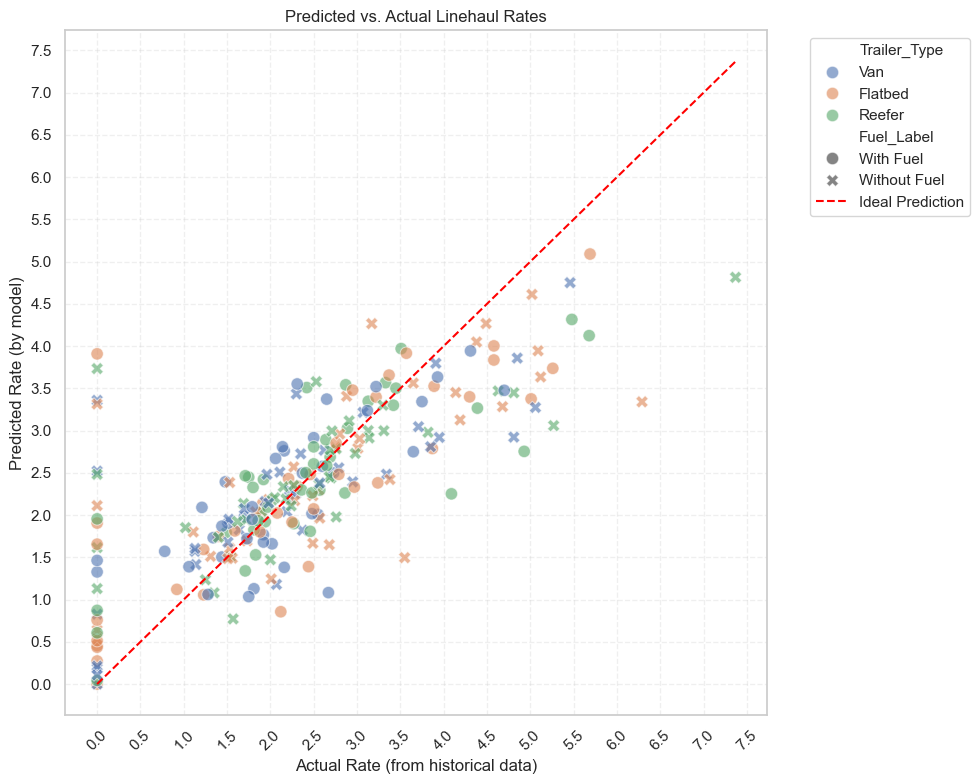

In [22]:
if 'y_test' in locals() and 'y_pred' in locals():
    results_df = pd.DataFrame({
        'Actual_Rate': y_test,
        'Predicted_Rate': y_pred,
    })
    
    if 'trailer_type' in df_model.columns:
        test_indices = df_model.index[df_model.index.isin(df_model.index[-len(y_test):])]
        results_df['Trailer_Type'] = df_model.loc[test_indices, 'trailer_type'].values[:len(y_test)]
    
    if 'include_fuel' in df_model.columns:
        test_indices = df_model.index[df_model.index.isin(df_model.index[-len(y_test):])]
        results_df['Fuel_Included'] = df_model.loc[test_indices, 'include_fuel'].values[:len(y_test)]
        results_df['Fuel_Label'] = results_df['Fuel_Included'].map({True: 'With Fuel', False: 'Without Fuel'})
    
    plt.figure(figsize=(10, 8))
    
    if 'Fuel_Label' in results_df.columns:
        # With fuel separation
        sns.scatterplot(data=results_df, x='Actual_Rate', y='Predicted_Rate', 
                        hue='Trailer_Type', style='Fuel_Label', alpha=0.6, s=80)
    elif 'Trailer_Type' in results_df.columns:
        # Without fuel separation
        sns.scatterplot(data=results_df, x='Actual_Rate', y='Predicted_Rate', 
                        hue='Trailer_Type', alpha=0.6)
    else:
        plt.scatter(results_df['Actual_Rate'], results_df['Predicted_Rate'], alpha=0.6)
    
    min_rate = min(results_df['Actual_Rate'].min(), results_df['Predicted_Rate'].min())
    max_rate = max(results_df['Actual_Rate'].max(), results_df['Predicted_Rate'].max())
    plt.plot([min_rate, max_rate], [min_rate, max_rate], color='red', linestyle='--', label='Ideal Prediction')
    
    tick_range = np.arange(min_rate, max_rate + 0.5, 0.5)
    plt.xticks(tick_range, rotation=45)
    plt.yticks(tick_range)
    
    plt.xlabel("Actual Rate (from historical data)")
    plt.ylabel("Predicted Rate (by model)")
    plt.title("Predicted vs. Actual Linehaul Rates")
    
    if 'Trailer_Type' in results_df.columns or 'Fuel_Label' in results_df.columns:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot create visualization - no model results available.")